# This code is to transcribe audio into draft transcript first. Then will be cleaned further with manual checking



In [ ]:
!pip install openai-whisper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 39.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=ce1e0e65cad0b22edc9bd4c02b54896b71b958979280c7aac7611f80621cd686
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:
import whisper

# !whisper --help

In [ ]:
import whisper

model = whisper.load_model('small')
 
 

100%|████████████████████████████████████████| 461M/461M [00:01<00:00, 255MiB/s]


In [ ]:
import os
# -- from whisper.utils import get_writer
import csv
 
file_name = 'your_trascript_file_name.tsv'

folder = 'your_transcript_file_location'
with open (file_name, "w", newline="", encoding ="utf-8") as tsvfile:
  writer = csv.writer(tsvfile, delimiter='\t')

  #write header row
  writer.writerow(["filename" ,"sentence"])
  for filename in os.listdir(folder):
    if not filename.lower().endswith((".wav", ".mp3", ".m4a", ".flac", ".webm")):
            continue
    print(filename)
    source = folder + filename
    result = model.transcribe(source)
    print(result["text"])
    text = result["text"].strip()
    writer.writerow([filename,text])
    tsvfile.flush()

print("Done. Saved to:", file_name)




insurance_audio_ms_MY_0.mp3
 e tuba o processo.
insurance_audio_ms_MY_1.mp3
 sila bayar 80 ribu. Lepas tu ambil bill, you hantar ke UP agent untuk claim. And it is still up to the company ya untuk disaipi claim.Sometimes dia akan reject UP claim, sometimes dia akan bayar separuh je. Jadi you tak nak lah ada this tidak kepastian ataupun uncertainties lah ya senang cakap. Contohnya kalau ni tinggal dikota Damansara lah for example ya. Hospital dekat dekat you adalah Thompson Hospital, Ramsey, Syme Dabi dekat arah Damansara ataupun Sanway Hospital dekat Bandar Sanway.
insurance_audio_ms_MY_2.mp3
 Bila you find the agent, semuanya bunga-bunga saja yang di cita. Oh, itu boleh, ini boleh. Everything as per charge, dia kata. Ano limit tinggi, bercutang juta. Last hand limit unlimited. Tapi berniat paling penting dalam insurans dan juga warrantier yang saya cakap adalah service.
insurance_audio_ms_MY_3.mp3
 lebih baik di hospital luar negara. Mungkin the specialist ataupun equipment tu tak ada

In [ ]:
import os
import librosa
import pandas as pd
import soundfile as sf

#append audio file path to the trancsript
folder = 'your_audio_file_location'


records = []

for filename in os.listdir(folder):
    if not filename.lower().endswith((".wav", ".mp3", ".m4a", ".flac", ".webm")):
            continue
    print(filename)
    path = os.path.join(folder, filename)
    # print(path)
    info = sf.info(path)
            # Load audio for duration
    audio, sr = librosa.load(path, sr=None)
    duration = len(audio) / sr

    records.append({
            "file": filename,
            "sampling_rate": sr,
            "channels": info.channels,
            "duration_sec": duration
        })



df = pd.DataFrame(records)


insurance_audio_ms_MY_0.mp3
insurance_audio_ms_MY_1.mp3
insurance_audio_ms_MY_2.mp3
insurance_audio_ms_MY_3.mp3
insurance_audio_ms_MY_4.mp3
insurance_audio_ms_MY_5.mp3
insurance_audio_ms_MY_6.mp3
insurance_audio_ms_MY_7.mp3
insurance_audio_ms_MY_8.mp3
insurance_audio_ms_MY_9.mp3
insurance_audio_ms_MY_10.mp3
insurance_audio_ms_MY_11.mp3
insurance_audio_ms_MY_12.mp3
insurance_audio_ms_MY_13.mp3
insurance_audio_ms_MY_14.mp3
insurance_audio_ms_MY_15.mp3
insurance_audio_ms_MY_16.mp3
insurance_audio_ms_MY_17.mp3
insurance_audio_ms_MY_18.mp3
insurance_audio_ms_MY_19.mp3
insurance_audio_ms_MY_20.mp3
insurance_audio_ms_MY_21.mp3
insurance_audio_ms_MY_22.mp3
insurance_audio_ms_MY_23.mp3
insurance_audio_ms_MY_24.mp3
insurance_audio_ms_MY_25.mp3
insurance_audio_ms_MY_26.mp3
insurance_audio_ms_MY_27.mp3
insurance_audio_ms_MY_28.mp3
insurance_audio_ms_MY_29.mp3
insurance_audio_ms_MY_30.mp3
insurance_audio_ms_MY_31.mp3
insurance_audio_ms_MY_32.mp3
insurance_audio_ms_MY_33.mp3
insurance_audio_ms_MY_34

In [ ]:
df.head()

,file,sampling_rate,channels,duration_sec
0,insurance_audio_ms_MY_0.mp3,16000,1,1.376
1,insurance_audio_ms_MY_1.mp3,16000,1,29.216
2,insurance_audio_ms_MY_2.mp3,16000,1,17.584
3,insurance_audio_ms_MY_3.mp3,16000,1,25.104
4,insurance_audio_ms_MY_4.mp3,16000,1,28.288


In [ ]:
print("Sampling Rate Distribution:")
print(df["sampling_rate"].value_counts())

print("\nChannel Distribution:")
print(df["channels"].value_counts())

print("\nAudio Duration (seconds):")
print(df["duration_sec"].describe())

Sampling Rate Distribution:
sampling_rate
16000    600
Name: count, dtype: int64

Channel Distribution:
channels
1    600
Name: count, dtype: int64

Audio Duration (seconds):
count    600.000000
mean       8.586209
std        8.437668
min        1.171687
25%        2.908000
50%        4.992000
75%       10.254000
max       29.816000
Name: duration_sec, dtype: float64


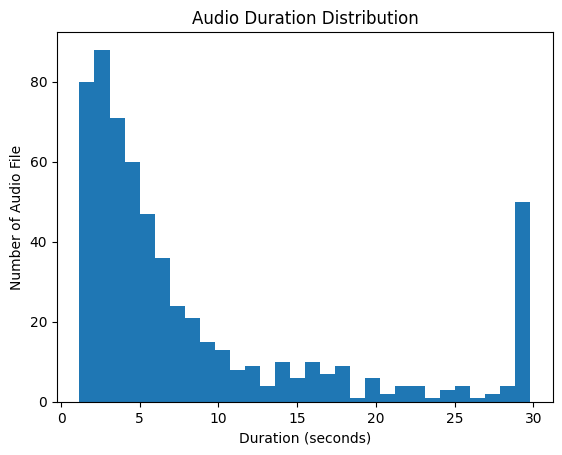

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["duration_sec"], bins=30)
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Audio File")
plt.title("Audio Duration Distribution")
plt.show()

In [ ]:
total_duration_sec = df["duration_sec"].sum()
print("Total audio duration (seconds):", total_duration_sec)

Total audio duration (seconds): 5151.7255625


In [ ]:
total_duration_minutes = total_duration_sec / 60
print("Total audio duration (seconds):", total_duration_minutes)

Total audio duration (seconds): 85.86209270833334


In [ ]:
total_duration_hours = total_duration_sec / 3600
print("Total audio duration (hours):", round(total_duration_hours, 2))

Total audio duration (hours): 1.43


In [ ]:
df = pd.read_csv(
    "your_audio_transcript_file_location.tsv",
    sep="\t"  # Important for TSV files
)

# Quick check
print(df.head())

                      filename  \
0  insurance_audio_ms_MY_0.mp3   
1  insurance_audio_ms_MY_1.mp3   
2  insurance_audio_ms_MY_2.mp3   
3  insurance_audio_ms_MY_3.mp3   
4  insurance_audio_ms_MY_4.mp3   

                                            sentence  
0                                   itu baru proses.  
1  sila bayar lapan puluh ribu. Lepas tu you ambi...  
2  Bila you jumpa agent ya, semuanya bunga-bunga ...  
3  lebih baik di hospital luar negara. Maybe the ...  
4  patutnya sampai golden years sahajalah enam pu...  


Columns: Index(['filename', 'sentence'], dtype='object')
                      filename  \
0  insurance_audio_ms_MY_0.mp3   
1  insurance_audio_ms_MY_1.mp3   
2  insurance_audio_ms_MY_2.mp3   
3  insurance_audio_ms_MY_3.mp3   
4  insurance_audio_ms_MY_4.mp3   

                                            sentence  
0                                   itu baru proses.  
1  sila bayar lapan puluh ribu. Lepas tu you ambi...  
2  Bila you jumpa agent ya, semuanya bunga-bunga ...  
3  lebih baik di hospital luar negara. Maybe the ...  
4  patutnya sampai golden years sahajalah enam pu...  

Character length statistics:
count    600.000000
mean     148.898333
std      159.046674
min        5.000000
25%       44.750000
50%       81.000000
75%      181.000000
max      652.000000
Name: char_len, dtype: float64

Word count statistics:
count    600.000000
mean      24.006667
std       25.354909
min        1.000000
25%        7.000000
50%       13.000000
75%       29.000000
max      111.000000
Nam

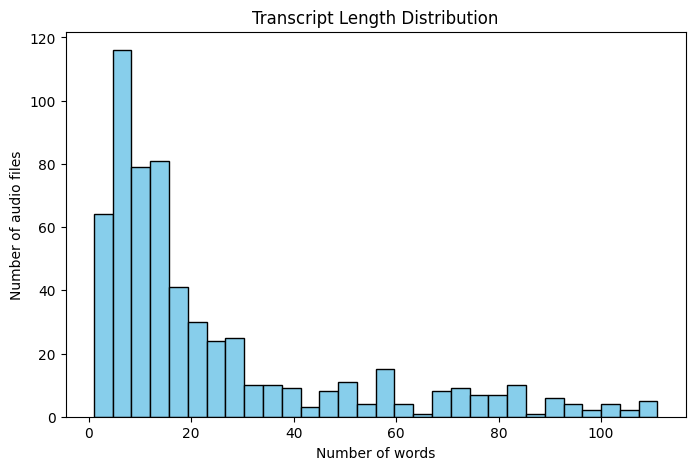


Very short transcripts (<=2 words): 12
Very long transcripts (>50 words): 93


In [ ]:
# Quick peek
print("Columns:", df.columns)
print(df.head())

# 2️⃣ Create transcript length features
df["char_len"] = df["sentence"].astype(str).apply(len)         # characters
df["word_count"] = df["sentence"].astype(str).apply(lambda x: len(x.split()))  # words

# 3️⃣ Summary statistics
print("\nCharacter length statistics:")
print(df["char_len"].describe())

print("\nWord count statistics:")
print(df["word_count"].describe())

# 4️⃣ Histogram of word counts
plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Number of words")
plt.ylabel("Number of audio files")  # safer than 'utterances'
plt.title("Transcript Length Distribution")
plt.show()

# 5️⃣ Check very short and very long transcripts
very_short = (df["word_count"] <= 2).sum()
very_long = (df["word_count"] > 50).sum()

print(f"\nVery short transcripts (<=2 words): {very_short}")
print(f"Very long transcripts (>50 words): {very_long}")

In [ ]:
df = pd.read_csv(
    "your_audio_transcript_file_location.tsv",
    sep="\t"  # Important for TSV files
)

# Quick check
print(df.head())

                      filename  \
0  insurance_audio_ms_MY_0.mp3   
1  insurance_audio_ms_MY_1.mp3   
2  insurance_audio_ms_MY_2.mp3   
3  insurance_audio_ms_MY_3.mp3   
4  insurance_audio_ms_MY_4.mp3   

                                            sentence  
0                                   itu baru proses.  
1  sila bayar lapan puluh ribu. Lepas tu you ambi...  
2  Bila you jumpa agent ya, semuanya bunga-bunga ...  
3  lebih baik di hospital luar negara. Maybe the ...  
4  patutnya sampai golden years sahajalah enam pu...  
